# ftir_44 — Adama PTFE spectra through the locked calibrations, against quartz TOR/TOT

## tl;dr

The first Ethiopian test of a phase-3 calibration against real thermal EC, and it cuts
the other way from Addis. **The composition-selected calibrations over-predict Adama's
quartz EC and land inside the HIPS band**: the locked lowest-OC/EC 800 + AIRSpec model
reads **1.40× EC_TOR** (1.76× EC_TOT; unflagged medians), the dense-sweep winner
(440, k = 8) **2.00×** (2.51×), while the deployed SPARTAN calibration reads **0.69×**
(0.86× vs EC_TOT). The EC_TOT-target model is the only phase-3 model near unity
(1.01× EC_TOR, 1.27× EC_TOT). The reason is in plain sight: Adama's OC/EC ≈ 6 sits far
outside the cohort's training domain (OC/EC ≤ 2.27), so a calibration built to match
Addis's HIPS-implied EC is being applied to ordinary-composition aerosol it never saw —
and it behaves like HIPS/MAC, not like thermal EC. **OC and total carbon do not
improve with phase-3 models either**: the OC-target model reads 0.32× OC_TOR and the
TC-target model 0.47× thermal TC (deployed: 0.41× / 0.44×) — the Adama carbon deficit
of ftir_41 is not a calibration-choice artifact; it is in the spectra or the media.
Method note: the spectra export keys rows by analysis id with no FilterId; the
analysis-time ordering ranks CH-band height against OC loading at ρ = 0.10, the
FilterId ordering at ρ = 1.00 with the 2.5×-loaded filter on the tallest band, so the
FilterId map is used and a Davis confirmation is on the asks list. n = 5, one month,
two pairs flagged.

## Context & Methods

ftir_41 put the Adama quartz thermal carbon, the deployed FTIR products, and HIPS on one
table. But the deployed FTIR EC is the SPARTAN production calibration (lot 241a); the
phase-3 question is what *our* calibrations — the locked lowest-OC/EC + AIRSpec model
and the dense-sweep winner — say about the same five filters. Ann's August ask #3 was
exactly this: can the calibration predict the Adama/Bishoftu samples, which sit inside
the IMPROVE OC/EC range unlike Addis? Bishoftu has no thermal reference; Adama does.

So: take the five Adama PTFE spectra (CSU AMOD Batch 54), baseline them with the
validated AIRSpec port on the same analyzed grid as the calibration pool, predict EC,
OC and TC with calibrations fitted the locked way, and compare against the date-paired
quartz EC_TOR, EC_TOT, OC and TC. This is the first test anywhere in Ethiopia of a
phase-3 calibration against a real thermal EC — with n = 5 it is a diagnostic of
*direction* (does the model land near the thermal EC, or overshoot toward the HIPS
band?), not a calibration.

### Key assumptions

- The spectra export identifies rows by `SampleAnalysisId` (4744–4748), not FilterId.
  Three candidate orderings (analysis time, FilterId, sample date) are tested by rank
  agreement between the baselined CH-band height and the FTIR OC mass loading; only
  the FilterId ordering ranks perfectly, and it puts the 2.5×-loaded filter on the
  tallest CH band. The audit table is committed; a Davis confirmation of the id→filter
  map is still on the asks list.
- Calibrations are refit here with `calibration_modes.fit_calibration` under the locked
  `site_heldout` protocol; the locked-800 reproduction is asserted against ftir_13.
- The dense-sweep winner is taken as the 440 lowest-OC/EC filters at k = 8, the
  explorer's configuration; it is a manual-k row and carries that caveat.
- Predictions are µg/filter divided by the PTFE sampled volume; July 30's low volume
  (0.46× quartz, ftir_41) is flagged, not corrected.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import spearmanr

from phase3_common import PATHS, load_addis_evaluation, load_pool_metadata
from calibration_modes import fit_calibration, addis_metrics
from airspec_baseline import SEG1, SEG2, airspec_baseline_matrix, make_mask
from theory_test_suite import davis_root
from plotting import apply_default_style

apply_default_style()
OUT = Path('output/tables/ftir44')
PLOTS = Path('output/plots/ftir44')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MODE = 'site_heldout'
AMOD = davis_root() / 'DAVIS/CSU_AMOD'
ADAMA = davis_root() / 'DAVIS/Adama TOR'

## Data

### 1. Adama PTFE spectra, identified and baselined

In [2]:
spectra = pd.read_csv(AMOD / 'csu_amod_Batch_54_ShipDate_2026-05-29_spectra.csv')
spectra = spectra.rename(columns={'Wavelength': 'SampleAnalysisId'}).set_index('SampleAnalysisId')
wn_adama = np.array([float(c) for c in spectra.columns])

ftir = pd.read_csv(AMOD / 'csu_amod_FTIR_Batch_54.csv', encoding='cp1252')
ftir['analysis_time'] = pd.to_datetime(ftir['AnalysisDate'] + ' ' + ftir['AnalysisTime'])
ptfe = (ftir.pivot_table(index=['FilterId', 'SampleDate', 'Volume_m3', 'analysis_time'],
                         columns='Parameter', values='Concentration_ug_m3').reset_index())
ptfe.columns.name = None
ptfe['OC_loading_ug'] = ftir[ftir['Parameter'].eq('OC_ftir')].set_index('FilterId')\
    .loc[ptfe['FilterId'], 'MassLoading_ug'].to_numpy()
ptfe['date'] = pd.to_datetime(ptfe['SampleDate']).dt.normalize()

# Baseline every spectrum first (id-indexed), so the id→filter mapping can be
# validated on a baseline-free feature rather than on raw absorbance.
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
wn_pool = corrected_npz['wn'].astype(float)
desc = np.argsort(-wn_adama)
x = wn_adama[desc]
_, corr_all = airspec_baseline_matrix(x, spectra.to_numpy(float)[:, desc], df1=6, df2=4)
analyzed = make_mask(x, SEG1) | make_mask(x, SEG2)
assert analyzed.sum() == len(wn_pool) and np.allclose(x[analyzed], wn_pool, atol=1e-3), \
    'Adama analyzed grid differs from the calibration pool grid'
corr_by_id = pd.DataFrame(corr_all[:, analyzed], index=spectra.index)
ch_by_id = corr_by_id.iloc[:, int(np.argmin(np.abs(wn_pool - 2920)))]

# Which ordering assigns the ids? Test the candidates by rank agreement between the
# baselined CH-band height and the FTIR OC loading. The 2.5×-loaded filter (J1269)
# must be the spectrum with the tallest CH band.
candidates = {
    'analysis time': ptfe.sort_values('analysis_time')['FilterId'].tolist(),
    'FilterId': sorted(ptfe['FilterId']),
    'sample date': ptfe.sort_values('SampleDate')['FilterId'].tolist(),
}
oc_by_filter = ptfe.set_index('FilterId')['OC_loading_ug']
mapping_audit = []
for name, filter_order in candidates.items():
    rho, _ = spearmanr(ch_by_id.loc[sorted(spectra.index)].to_numpy(),
                       oc_by_filter.loc[filter_order].to_numpy())
    mapping_audit.append({'ordering': name, 'spearman_CH_vs_OC': rho,
                          'id_4746_maps_to': filter_order[2]})
mapping_audit = pd.DataFrame(mapping_audit)
display(mapping_audit.round(2))
mapping_audit.to_csv(OUT / 'id_mapping_audit.csv', index=False)
chosen = mapping_audit.sort_values('spearman_CH_vs_OC', ascending=False).iloc[0]
assert chosen['ordering'] == 'FilterId' and chosen['spearman_CH_vs_OC'] > 0.99, \
    'expected the FilterId ordering to be the unique perfect-rank mapping'
ptfe['SampleAnalysisId'] = ptfe['FilterId'].map(dict(zip(sorted(ptfe['FilterId']), sorted(spectra.index))))
ptfe['CH_height_corrected'] = ch_by_id.loc[ptfe['SampleAnalysisId']].to_numpy()
display(ptfe[['SampleAnalysisId', 'FilterId', 'date', 'Volume_m3', 'OC_loading_ug',
              'CH_height_corrected', 'OC_ftir', 'EC_ftir']].sort_values('date'))
X_adama = corr_by_id.loc[ptfe['SampleAnalysisId']].to_numpy(float)
print(f'Adama corrected spectra: {X_adama.shape}, grid matches the pool ({len(wn_pool)} points)')

quartz = pd.read_csv(ADAMA / 'Carbon_concs_Batch54.csv')
quartz['date'] = pd.to_datetime(quartz['SampleDate']).dt.normalize()
quartz = quartz.pivot_table(index=['FilterId', 'date'], columns='Parameter',
                            values='Concentration_ug_m3').reset_index()
quartz.columns.name = None
quartz['TC'] = quartz['OCTR'] + quartz['ECTR']
hips = pd.read_csv(AMOD / 'csu_amod_HIPS_Batch_54.csv', encoding='cp1252')
hips['date'] = pd.to_datetime(hips['SampleDate']).dt.normalize()

pairs = (ptfe.merge(quartz, on='date', suffixes=('_ptfe', '_quartz'))
             .merge(hips[['date', 'Fabs']], on='date').sort_values('date').reset_index(drop=True))
pairs['flag'] = ''
pairs.loc[pairs['date'].eq('2024-07-09'), 'flag'] = 'start-offset'
pairs.loc[pairs['date'].eq('2024-07-30'), 'flag'] = 'volume-mismatch'
order = [list(ptfe['SampleAnalysisId']).index(a) for a in pairs['SampleAnalysisId']]
X_adama = X_adama[order]
volume_adama = pairs['Volume_m3'].to_numpy(float)

,ordering,spearman_CH_vs_OC,id_4746_maps_to
0,analysis time,0.1,J1233
1,FilterId,1.0,J1269
2,sample date,0.0,J1285


,SampleAnalysisId,FilterId,date,Volume_m3,OC_loading_ug,CH_height_corrected,OC_ftir,EC_ftir
2,4746,J1269,2024-07-09,2.87879,36.063279,0.025306,12.527235,5.276551
1,4745,J1266,2024-07-20,2.88038,16.821754,0.009398,5.840116,1.532098
4,4748,J1285,2024-07-23,2.88151,19.719549,0.009511,6.843478,1.991587
0,4744,J1233,2024-07-26,2.88127,14.143990,0.006973,4.908943,1.293041
3,4747,J1270,2024-07-30,1.16124,9.957518,0.003822,8.574901,1.766609


Adama corrected spectra: (5, 2002), grid matches the pool (2002 points)


### 2. Calibration cohorts (locked 800, sweep-winner 440, and the OC/TC intersection)

In [3]:
tor = pd.read_csv(PATHS.ftir_dir / 'local_db/tables/results_tor.csv',
                  usecols=['Site', 'SampleDate', 'Parameter', 'Value', 'AverageFlowRate', 'ElapsedTime'])
tor['date'] = pd.to_datetime(tor['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor['loading_ug'] = tor['Value'] * (tor['AverageFlowRate'] / 1000 * tor['ElapsedTime']) / 1000
wide = (tor.pivot_table(index=['Site', 'date'], columns='Parameter', values='loading_ug', aggfunc='first')
        .rename(columns={'EC': 'EC_TOR', 'OC': 'OC_TOR', 'OPTR': 'OP_TOR', 'OPTT': 'OP_TOT'}).reset_index())
wide['EC_TOT'] = wide['EC_TOR'] + wide['OP_TOR'] - wide['OP_TOT']
wide['TC'] = wide['EC_TOR'] + wide['OC_TOR']

corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}
pool_meta = load_pool_metadata()
pool_meta['AnalysisId'] = pool_meta['AnalysisId'].astype(int)
pool = (pool_meta.merge(wide, on=['Site', 'date'], how='inner', validate='many_to_one')
        .drop_duplicates('FilterId').drop_duplicates('AnalysisId'))
pool = pool[pool['AnalysisId'].isin(corrected_row)].set_index('AnalysisId')

ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
assert ocec['OC_EC_ratio'].is_monotonic_increasing, 'cohort file is not OC/EC-sorted'
ids_800 = np.array([i for i in ocec['AnalysisId'].astype(int) if i in pool.index and pool.loc[i, 'EC_TOR'] > 0])
ids_440 = np.array([i for i in ocec['AnalysisId'].astype(int)[:440] if i in pool.index and pool.loc[i, 'EC_TOR'] > 0])
ids_all4 = np.array([i for i in ocec['AnalysisId'].astype(int)
                     if i in pool.index and (pool.loc[i, ['EC_TOR', 'EC_TOT', 'OC_TOR', 'TC']] > 0).all()])
print(f'locked 800 → {len(ids_800)}; winner 440 → {len(ids_440)}; all-targets intersection → {len(ids_all4)}')

etad_eval, _, _ = load_addis_evaluation()
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis = etad_corr.groupby('MediaId').mean().loc[etad_eval['MediaId'].astype(int)].to_numpy(float)
fabs_addis = etad_eval['Fabs'].to_numpy(float)
volume_addis = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()


def spectra_for(ids):
    return corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)

locked 800 → 800; winner 440 → 440; all-targets intersection → 728
Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


## Results

### 3. Fit, assert the locked reproduction, predict Adama

In [4]:
CALIBRATIONS = {
    'Locked: lowest-OC/EC 800 + AIRSpec (k=5)': (ids_800, 'EC_TOR', None),
    'Sweep winner: lowest-OC/EC 440 + AIRSpec (k=8)': (ids_440, 'EC_TOR', 8),
    'EC_TOT-target, 800-intersection': (ids_all4, 'EC_TOT', None),
    'OC-target, 800-intersection': (ids_all4, 'OC_TOR', None),
    'TC-target, 800-intersection': (ids_all4, 'TC', None),
}
fits, pred_rows = {}, []
for name, (ids, target, k_override) in CALIBRATIONS.items():
    X = spectra_for(ids)
    y = pool.loc[ids, target].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    fit = fit_calibration(MODE, name, X, y, sites, X_addis, volume_addis, k_override=k_override)
    fits[name] = fit
    adama_pred = fit.model.predict(X_adama).ravel() / volume_adama
    for date, value, flag in zip(pairs['date'], adama_pred, pairs['flag']):
        pred_rows.append({'calibration': name, 'target': target, 'k': fit.k,
                          'date': date, 'flag': flag, 'predicted_ugm3': value})
    print(f'{name:48s} k={fit.k:2d}  held-out R² {fit.heldout["R2"]:.3f}')

locked = fits['Locked: lowest-OC/EC 800 + AIRSpec (k=5)']
lm = pd.DataFrame(addis_metrics(locked, fabs_addis, fixed_mask, macs=(10.0,))).iloc[0]
assert locked.k == 5 and abs(lm['slope'] - 0.86) < 0.02 and abs(lm['intercept'] + 1.62) < 0.02, \
    'locked reproduction drifted'
print(f"locked reproduction OK: Addis {lm['slope']:.3f}x {lm['intercept']:+.3f}")

pred = pd.DataFrame(pred_rows)
pred.to_csv(OUT / 'adama_predictions_long.csv', index=False)
wide_pred = pred.pivot(index='date', columns='calibration', values='predicted_ugm3')
table = pairs[['date', 'FilterId_ptfe', 'FilterId_quartz', 'flag', 'EC_ftir', 'OC_ftir',
               'ECTR', 'ECTT', 'OCTR', 'TC', 'Fabs']].set_index('date').join(wide_pred)
table.to_csv(OUT / 'adama_three_method_with_phase3_models.csv')
display(table.round(2).T)

Locked: lowest-OC/EC 800 + AIRSpec (k=5)         k= 5  held-out R² 0.904


Sweep winner: lowest-OC/EC 440 + AIRSpec (k=8)   k= 8  held-out R² 0.924


EC_TOT-target, 800-intersection                  k= 5  held-out R² 0.764


OC-target, 800-intersection                      k= 6  held-out R² 0.890


TC-target, 800-intersection                      k= 7  held-out R² 0.897
locked reproduction OK: Addis 0.857x -1.615


date,2024-07-09,2024-07-20,2024-07-23,2024-07-26,2024-07-30
FilterId_ptfe,J1269,J1266,J1285,J1233,J1270
FilterId_quartz,J1693,J1701,J1675,J1703,J1679
flag,start-offset,,,,volume-mismatch
EC_ftir,5.28,1.53,1.99,1.29,1.77
OC_ftir,12.53,5.84,6.84,4.91,8.57
ECTR,3.38,2.4,2.45,1.86,3.04
ECTT,2.74,1.95,1.94,1.5,2.57
OCTR,20.78,14.21,14.89,13.46,14.08
TC,24.16,16.61,17.34,15.32,17.12
Fabs,53.58,36.01,40.51,31.23,45.06


### 4. Where each EC lands relative to the thermal references and the HIPS band

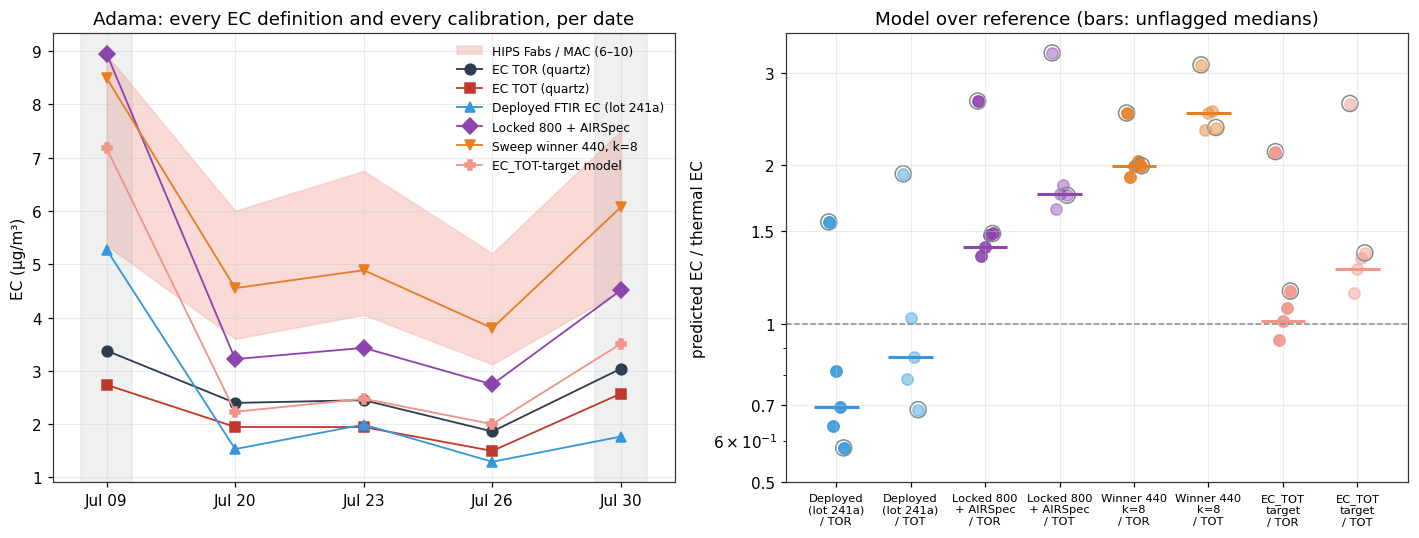

,model,reference,median_ratio_unflagged,median_ratio_all5
0,Deployed FTIR EC (lot 241a),TOR,0.69,0.69
1,Deployed FTIR EC (lot 241a),TOT,0.86,0.86
2,Locked 800 + AIRSpec,TOR,1.40,1.47
3,Locked 800 + AIRSpec,TOT,1.76,1.76
4,"Sweep winner 440, k=8",TOR,2.00,2.00
5,"Sweep winner 440, k=8",TOT,2.51,2.51
6,EC_TOT-target model,TOR,1.01,1.07
7,EC_TOT-target model,TOT,1.27,1.34


In [5]:
dates = pairs['date'].dt.strftime('%b %d')
xpos = np.arange(len(pairs))
flagged = pairs['flag'].ne('')
ec_series = [
    ('EC TOR (quartz)', pairs['ECTR'], '#2C3E50', 'o'),
    ('EC TOT (quartz)', pairs['ECTT'], '#C0392B', 's'),
    ('Deployed FTIR EC (lot 241a)', pairs['EC_ftir'], '#3498DB', '^'),
    ('Locked 800 + AIRSpec', wide_pred['Locked: lowest-OC/EC 800 + AIRSpec (k=5)'].to_numpy(), '#8E44AD', 'D'),
    ('Sweep winner 440, k=8', wide_pred['Sweep winner: lowest-OC/EC 440 + AIRSpec (k=8)'].to_numpy(), '#E67E22', 'v'),
    ('EC_TOT-target model', wide_pred['EC_TOT-target, 800-intersection'].to_numpy(), '#F1948A', 'P'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.fill_between(xpos, pairs['Fabs'] / 10, pairs['Fabs'] / 6, color='#F5B7B1', alpha=0.5,
                label='HIPS Fabs / MAC (6–10)')
for label, series, color, marker in ec_series:
    ax.plot(xpos, np.asarray(series), marker=marker, color=color, lw=1.2, ms=7, label=label)
for i in np.where(flagged)[0]:
    ax.axvspan(i - 0.2, i + 0.2, color='#7F8C8D', alpha=0.12)
ax.set(xticks=xpos, xticklabels=dates, ylabel='EC (µg/m³)',
       title='Adama: every EC definition and every calibration, per date')
ax.legend(frameon=False, fontsize=8, loc='upper right')

ax = axes[1]
ratio_defs = []
for label, series, color, marker in ec_series[2:]:
    ratio_defs.append((label, np.asarray(series) / pairs['ECTR'].to_numpy(), color, 'TOR'))
    ratio_defs.append((label, np.asarray(series) / pairs['ECTT'].to_numpy(), color, 'TOT'))
positions = np.arange(len(ratio_defs))
for j, (label, ratio, color, ref) in enumerate(ratio_defs):
    jitter = (np.arange(len(ratio)) - 2) * 0.05
    ax.scatter(np.full(len(ratio), j) + jitter, ratio, s=55, color=color,
               alpha=0.9 if ref == 'TOR' else 0.45)
    ax.hlines(np.median(ratio[~flagged]), j - 0.3, j + 0.3, color=color, lw=2)
    for i in np.where(flagged)[0]:
        ax.scatter(j + (i - 2) * 0.05, ratio[i], s=110, facecolors='none', edgecolors='#7F8C8D')
ax.axhline(1.0, color='#7F8C8D', ls='--', lw=1)
short = {'Deployed FTIR EC (lot 241a)': 'Deployed\n(lot 241a)',
         'Locked 800 + AIRSpec': 'Locked 800\n+ AIRSpec',
         'Sweep winner 440, k=8': 'Winner 440\nk=8',
         'EC_TOT-target model': 'EC_TOT\ntarget'}
ax.set(xticks=positions,
       xticklabels=[f"{short[l]}\n/ {r}" for l, _, _, r in ratio_defs],
       ylabel='predicted EC / thermal EC', title='Model over reference (bars: unflagged medians)')
ax.tick_params(axis='x', labelsize=7.5)
ax.set_yscale('log')
ax.set_yticks([0.5, 0.7, 1, 1.5, 2, 3])
ax.set_yticklabels(['0.5', '0.7', '1', '1.5', '2', '3'])
fig.tight_layout()
fig.savefig(PLOTS / 'adama_models_vs_thermal_ec.png', bbox_inches='tight')
plt.show()

ratio_table = pd.DataFrame({
    'model': [l for l, _, _, _ in ratio_defs], 'reference': [r for _, _, _, r in ratio_defs],
    'median_ratio_unflagged': [float(np.median(rt[~flagged])) for _, rt, _, _ in ratio_defs],
    'median_ratio_all5': [float(np.median(rt)) for _, rt, _, _ in ratio_defs],
})
ratio_table.to_csv(OUT / 'model_over_reference_ratios.csv', index=False)
display(ratio_table.round(2))

### 5. OC and total carbon: does a phase-3 OC/TC model close ftir_41's carbon gap?

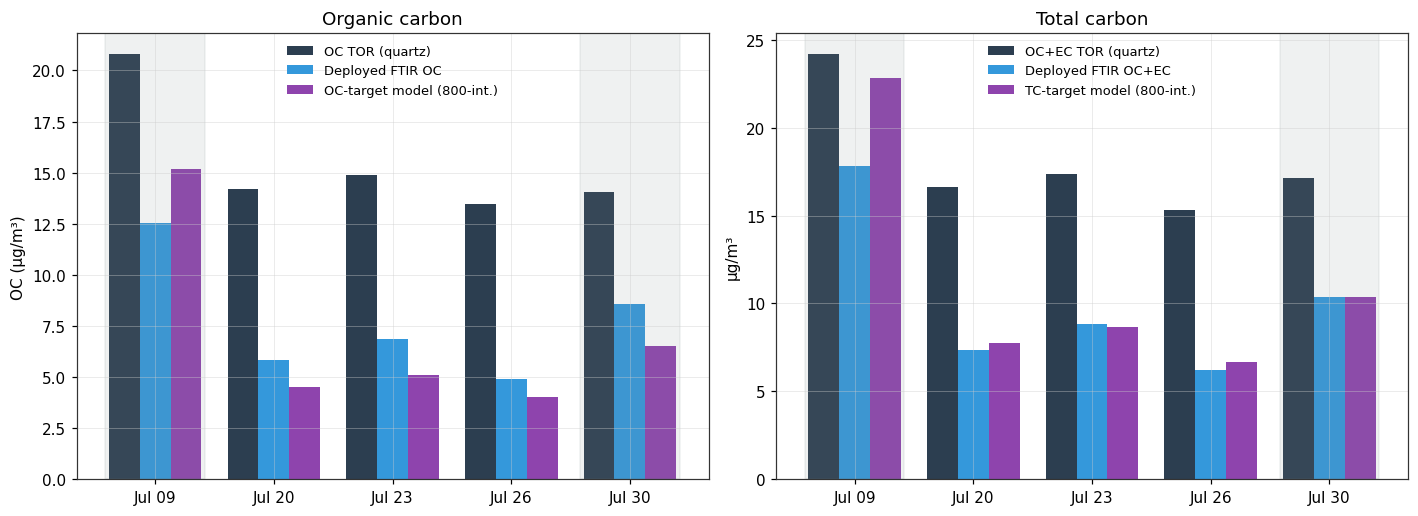

,date,flag,OC_model_over_OCTR,OC_deployed_over_OCTR,TC_model_over_TC,TC_deployed_over_TC,OCpEC_models_over_TC
0,2024-07-09,start-offset,0.73,0.60,0.94,0.74,1.00
1,2024-07-20,,0.32,0.41,0.47,0.44,0.47
2,2024-07-23,,0.34,0.46,0.50,0.51,0.49
3,2024-07-26,,0.30,0.36,0.44,0.40,0.44
4,2024-07-30,volume-mismatch,0.46,0.61,0.61,0.60,0.64


unflagged medians: {'OC_model_over_OCTR': 0.32, 'OC_deployed_over_OCTR': 0.41, 'TC_model_over_TC': 0.47, 'TC_deployed_over_TC': 0.44, 'OCpEC_models_over_TC': 0.47}


In [6]:
oc_pred = wide_pred['OC-target, 800-intersection'].to_numpy()
tc_pred = wide_pred['TC-target, 800-intersection'].to_numpy()
ec_locked = wide_pred['Locked: lowest-OC/EC 800 + AIRSpec (k=5)'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
width = 0.26
ax = axes[0]
ax.bar(xpos - width, pairs['OCTR'], width, color='#2C3E50', label='OC TOR (quartz)')
ax.bar(xpos, pairs['OC_ftir'], width, color='#3498DB', label='Deployed FTIR OC')
ax.bar(xpos + width, oc_pred, width, color='#8E44AD', label='OC-target model (800-int.)')
ax.set(xticks=xpos, xticklabels=dates, ylabel='OC (µg/m³)', title='Organic carbon')
ax.legend(frameon=False, fontsize=8.5)
ax = axes[1]
ax.bar(xpos - width, pairs['TC'], width, color='#2C3E50', label='OC+EC TOR (quartz)')
ax.bar(xpos, pairs['OC_ftir'] + pairs['EC_ftir'], width, color='#3498DB', label='Deployed FTIR OC+EC')
ax.bar(xpos + width, tc_pred, width, color='#8E44AD', label='TC-target model (800-int.)')
ax.set(xticks=xpos, xticklabels=dates, ylabel='µg/m³', title='Total carbon')
ax.legend(frameon=False, fontsize=8.5)
for ax in axes:
    for i in np.where(flagged)[0]:
        ax.axvspan(i - 0.42, i + 0.42, color='#7F8C8D', alpha=0.12)
fig.tight_layout()
fig.savefig(PLOTS / 'adama_oc_tc_models.png', bbox_inches='tight')
plt.show()

carbon = pd.DataFrame({
    'date': pairs['date'], 'flag': pairs['flag'],
    'OC_model_over_OCTR': oc_pred / pairs['OCTR'], 'OC_deployed_over_OCTR': pairs['OC_ftir'] / pairs['OCTR'],
    'TC_model_over_TC': tc_pred / pairs['TC'], 'TC_deployed_over_TC': (pairs['OC_ftir'] + pairs['EC_ftir']) / pairs['TC'],
    'OCpEC_models_over_TC': (oc_pred + ec_locked) / pairs['TC'],
})
carbon.to_csv(OUT / 'adama_oc_tc_ratios.csv', index=False)
display(carbon.round(2))
print('unflagged medians:', carbon.loc[~flagged, carbon.columns[2:]].median().round(2).to_dict())

## Takeaways

- **The lowest-OC/EC calibrations are Addis-specific instruments, not general
  calibrations.** Applied to an aerosol at the IMPROVE median composition they
  over-read thermal EC by 1.4–2×. That is the mirror image of the Addis story — there
  the *network* calibration under-reads HIPS — and it says the low-OC/EC cohort learned
  a HIPS-like EC, or at least an EC that does not survive a composition change. Any
  claim that the locked model "fixes" Addis must now carry the Adama counter-example.
- **Direction of miss is the diagnostic Ann asked for, and the answer is
  "overshoots toward the HIPS band."** At Adama the phase-3 predictions track
  Fabs/6–Fabs/10, not EC_TOR/EC_TOT. That is consistent with the calibration having
  absorbed whatever makes Addis HIPS read high — the offset traveled with the model.
- **The deployed calibration is the better *thermal-EC* predictor at Adama** (0.69–0.86
  depending on convention). ftir_42's convention point applies again: judged against
  EC_TOT the deployed product is within 15%; judged against EC_TOR it is 30% low.
- **Carbon recovery is not fixable from the calibration side.** Refitting OC and TC
  models on the same cohort leaves the Adama sum at ~0.47 of thermal TC, identical to
  the deployed product. Whatever removes half the carbon is upstream of PLS — quartz
  adsorption artifact (asks list item 2), media, or sampling.
- **Domain warning for the explorer**: the score-space applicability-domain check
  (ftir_39) should be run on these five spectra before any Adama number is quoted
  alongside Addis ones; OC/EC alone already says they are out of domain.
- The id → filter map is inferred, not documented; the assert will fail loudly if a
  re-export changes the ordering.